<a href="https://colab.research.google.com/github/soumitadechoudhury-lab/boston-housing-prediction/blob/main/Boston_housing_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Boston Housing Price Prediction

## Objective
The objective of this project is to analyze the Boston Housing dataset and build regression models to predict housing prices based on different features.

## Tools & Libraries Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load Boston Housing Dataset
boston = fetch_openml(name='boston', version=1, as_frame=True)

# Store dataset in dataframe
df = boston.frame

# Display first 5 rows
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
# Shape of dataset
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns in dataset:\n")
print(df.columns)

# Dataset information
print("\nDataset Information:\n")
df.info()

Shape of dataset: (506, 14)

Columns in dataset:

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB


## Feature Description

- CRIM → Crime rate per town
- ZN → Residential land zoned for large lots
- INDUS → Non-retail business acres
- CHAS → Charles River dummy variable
- NOX → Nitric oxide concentration
- RM → Average number of rooms per dwelling
- AGE → Proportion of old houses
- DIS → Distance to employment centers
- RAD → Accessibility to highways
- TAX → Property tax rate
- PTRATIO → Pupil-teacher ratio
- B → Proportion related to Black population statistic
- LSTAT → Lower status population percentage
- MEDV → Median house value (Target Variable)

In [4]:
df.describe()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000,50.000000


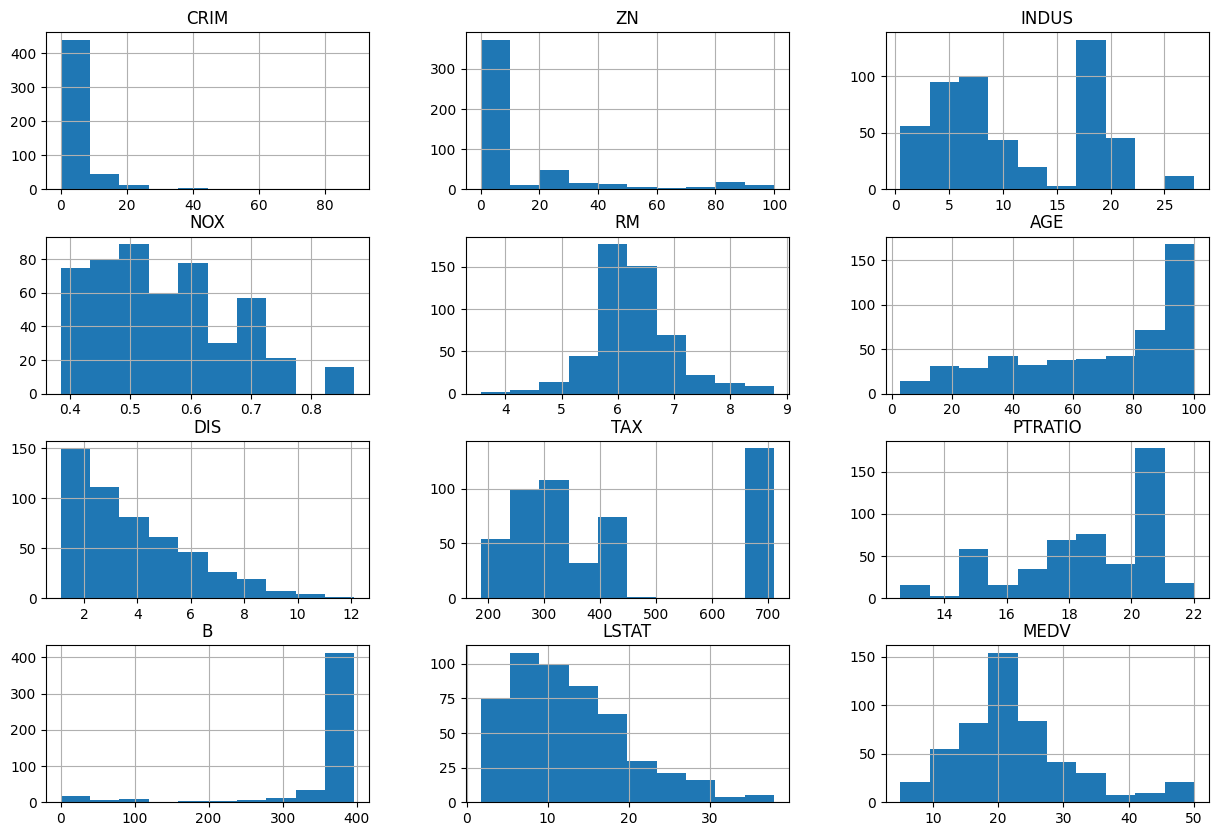

In [5]:
# Histograms for all numerical columns
df.hist(figsize=(15,10))

plt.show()

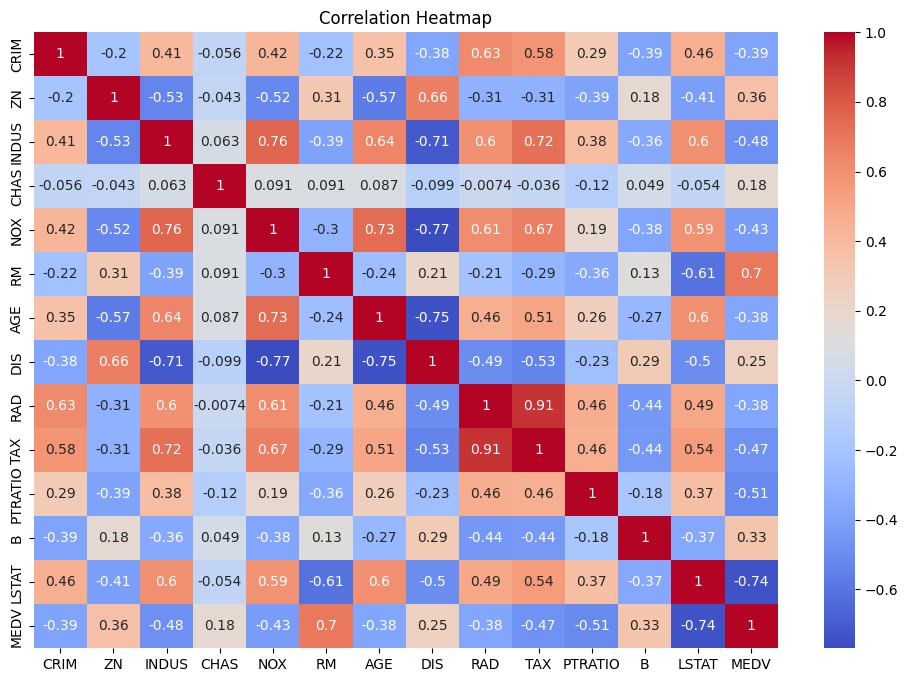

In [6]:
# Correlation heatmap

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

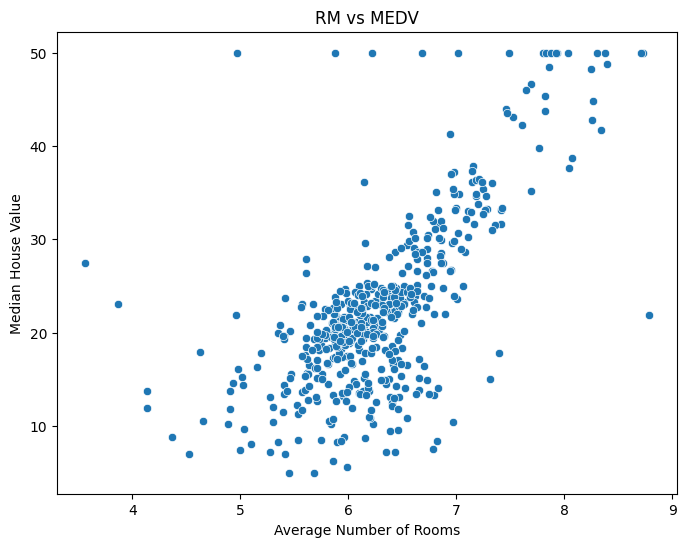

In [7]:
# Scatter plot between RM and MEDV

plt.figure(figsize=(8,6))

sns.scatterplot(x=df['RM'], y=df['MEDV'])

plt.title("RM vs MEDV")

plt.xlabel("Average Number of Rooms")

plt.ylabel("Median House Value")

plt.show()

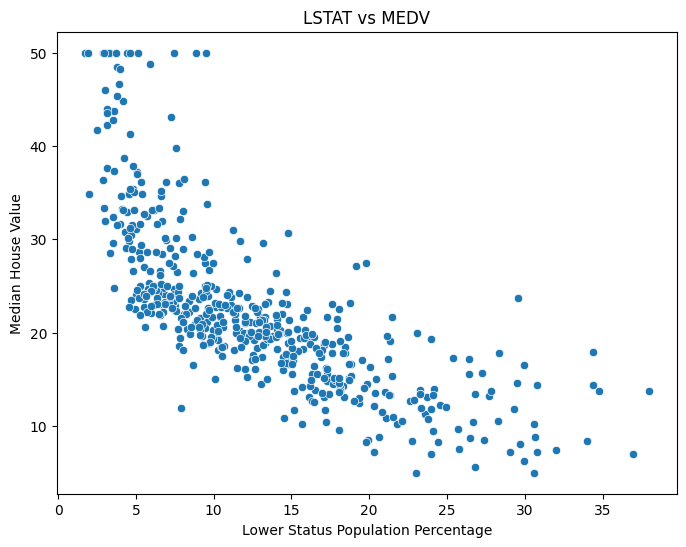

In [8]:
# Scatter plot between LSTAT and MEDV

plt.figure(figsize=(8,6))

sns.scatterplot(x=df['LSTAT'], y=df['MEDV'])

plt.title("LSTAT vs MEDV")

plt.xlabel("Lower Status Population Percentage")

plt.ylabel("Median House Value")

plt.show()

In [9]:
# Convert all columns to numeric
df = df.apply(pd.to_numeric)

# Define features and target
X = df.drop('MEDV', axis=1)
y = df['MEDV']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Show first 5 predictions
print(y_pred[:5])

[28.99672362 36.02556534 14.81694405 25.03197915 18.76987992]


In [10]:
# Evaluate model performance

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)

print("R² Score:", r2)

RMSE: 4.928602182665332
R² Score: 0.6687594935356326


In [11]:
# Compare actual and predicted values

comparison = pd.DataFrame({
    'Actual Value': y_test,
    'Predicted Value': y_pred
})

comparison.head()

,Actual Value,Predicted Value
173,23.6,28.996724
274,32.4,36.025565
491,13.6,14.816944
72,22.8,25.031979
452,16.1,18.769880


# Conclusion

This project analyzed the Boston Housing dataset using exploratory data analysis and linear regression techniques.

Key findings from the analysis include:

- RM (average number of rooms) showed a strong positive relationship with housing prices.
- LSTAT (lower status population percentage) showed a strong negative relationship with housing prices.
- Correlation heatmaps and scatter plots helped identify important patterns in the dataset.
- A Linear Regression model was trained to predict housing prices based on multiple features.
- The model produced reasonably accurate predictions, although slight differences between actual and predicted values were observed.
- Evaluation metrics such as RMSE and R² Score were used to measure model performance.
- The Linear Regression model achieved an R² Score of 0.668, indicating that the model explains approximately 66.8% of the variation in housing prices.
- The results suggest that the model captures major pricing trends reasonably well, although some prediction error remains due to the complexity of real-world housing data.

Overall, this project demonstrates the complete machine learning workflow including:
- Data loading
- Data exploration
- Visualization
- Feature selection
- Model training
- Prediction
- Model evaluation